# UBDS 2026: Basic Python
## Day 4  : Pandas & Matplotlib

### Topics covered
1. Learn to handle **large datasets** using Pandas. / Вивчимо як працювати з **великими датасетами** використовуючи пандас
2. Perform **basic numerical analyses** with NumPy. / Проведемо базовий **стат аналіз** викорстовуючи numpy
3. Visualise data using Matplotlib. / Візуалізуємо дані використовуючи matplotlib
4. Explore real-world biological data from the **AnAge database**. / Дослідимо реальні біологічна данні використовуючи  **AnAge** датасет

## Resources
### Pandas documentation: https://pandas.pydata.org/docs/user_guide/index.html
### Graph examples: https://python-graph-gallery.com


### We will use the AnAge dataset ('anage_data.tsv'); a curated database of ageing and life history in animals, including extensive longevity records / Ми будемо використовувати датасет  **AnAge**, що є очищеною базоданних про старіння і довголіття у тварин.

# Step 0: Import the tools we need

- `pandas` helps us work with tables of data, given the alias; pd / допомогає нам працювати з таблицями, коротка назва pd
- `numpy` is needed to work with numerical data, given the alias; np / потрібенн для роботи з числовими данними, коротка назва np
- `matplotlib` helps us make plots, given the alias; plt / потрібен для роботи з графіками, коротка назва plt

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


# Step 1: Load the Dataset 

- Make sure the file is in the same folder as your notebook / Перевірте що файл знаходиться в потрібній папці

In [78]:
# Read in the dataframe - use separator=tab as we have a tab separated file / Читаємо файл вказуючи що розділовий знак це Tab
df = pd.read_csv("anage_data.tsv", sep='\t') 

# Filter the dataframe columns to the ones we are interested in / Фільтруємо потрібні колонки
df = df[['Class', 'Order', 'Family', 'Genus', 'Species', 'Common name', 'Female maturity (days)', 'Male maturity (days)', 'Gestation/Incubation (days)', 'Weaning (days)', 'Litter/Clutch size', 'Litters/Clutches per year', 'Inter-litter/Interbirth interval', 'Birth weight (g)', 'Weaning weight (g)', 'Adult weight (g)', 'Growth rate (1/days)', 'Maximum longevity (yrs)', 'Source', 'Specimen origin', 'Sample size', 'Data quality', 'IMR (per yr)', 'MRDT (yrs)', 'Metabolic rate (W)', 'Body mass (g)', 'Temperature (K)']]
df.head(5)  # Show first 5 rows

,Class,Order,Family,Genus,Species,Common name,Female maturity (days),Male maturity (days),Gestation/Incubation (days),Weaning (days),...,Maximum longevity (yrs),Source,Specimen origin,Sample size,Data quality,IMR (per yr),MRDT (yrs),Metabolic rate (W),Body mass (g),Temperature (K)
0,Polychaeta,Sabellida,Siboglinidae,Escarpia,laminata,Escarpia laminata,NaN,NaN,NaN,NaN,...,300.00,1466,wild,medium,acceptable,NaN,NaN,NaN,NaN,NaN
1,Polychaeta,Sabellida,Siboglinidae,Lamellibrachia,luymesi,Lamellibrachia luymesi,NaN,NaN,NaN,NaN,...,250.00,652,wild,small,acceptable,NaN,NaN,NaN,NaN,NaN
2,Polychaeta,Sabellida,Siboglinidae,Seepiophila,jonesi,Seepiophila jonesi,NaN,NaN,NaN,NaN,...,300.00,1467,wild,small,acceptable,NaN,NaN,NaN,NaN,NaN
3,Arachnida,Araneae,Theridiidae,Latrodectus,hasselti,Australian redback spider,NaN,NaN,NaN,NaN,...,NaN,NaN,unknown,medium,low,NaN,NaN,NaN,NaN,NaN
4,Branchiopoda,Diplostraca,Daphniidae,Daphnia,pulicaria,Daphnia,NaN,NaN,NaN,NaN,...,0.19,NaN,unknown,medium,acceptable,NaN,NaN,NaN,NaN,NaN


# EXERCISE 1 

1. What happens if you forget to specify sep='\t' when reading a tab delimited dataset? / Перевірте що буде якщо не вкажете sep='\t'
2. As well as the head() method there is a tail() method. What do you think it does?  / Що робить метод tail?
3. Both methods accept a single numeric parameter. What do you think it does? / Обидва методи приймають параметр, що він робить?

In [ ]:
#### Your Code Here ####


# Step 2: Explore the Dataset
- Get basic information about the dataset / Дослідіть базову інформацію про датасет

In [3]:
# How many rows?
print("Dataset length: ", len(df))

# How many rows and columns?
print("Dataset shape:", df.shape)

# How many cells in the table?
print("Dataset size: ", df.size)

# Column names
print("Columns:", df.columns.tolist())

# What are the data types of the columns?
print("Column data types: ", df.dtypes)

# Quick statistics of numeric columns
df.describe()

# Check how many Species are available in the dataset 
Species = df['Common name'].to_list()
print("Number of species: ", len(set(Species)))

# Check how many Orders are available in the dataset 
Order = df['Order'].to_list()
print("Number of orders: ", len(set(Order)))

# Longest lived species 
print(df.loc[df['Maximum longevity (yrs)'].idxmax()])

Dataset length:  4645
Dataset shape: (4645, 27)
Dataset size:  125415
Columns: ['Class', 'Order', 'Family', 'Genus', 'Species', 'Common name', 'Female maturity (days)', 'Male maturity (days)', 'Gestation/Incubation (days)', 'Weaning (days)', 'Litter/Clutch size', 'Litters/Clutches per year', 'Inter-litter/Interbirth interval', 'Birth weight (g)', 'Weaning weight (g)', 'Adult weight (g)', 'Growth rate (1/days)', 'Maximum longevity (yrs)', 'Source', 'Specimen origin', 'Sample size', 'Data quality', 'IMR (per yr)', 'MRDT (yrs)', 'Metabolic rate (W)', 'Body mass (g)', 'Temperature (K)']
Column data types:  Class                                object
Order                                object
Family                               object
Genus                                object
Species                              object
Common name                          object
Female maturity (days)              float64
Male maturity (days)                float64
Gestation/Incubation (days)         fl

# EXERCISE 2

1. Name the species with the largest body mass. / Назвіть вид з найбільшою масою тіла
2. What is the largest litter size? / А тепер з найбільшоб кількістю потомства
3. What is the shortest lived species? / А тепер найбільш короткоживучий вид

In [4]:
#### Your code here ####
print(df.loc[df['Body mass (g)'].idxmax()])

Class                                       Mammalia
Order                                    Proboscidea
Family                                  Elephantidae
Genus                                        Elephas
Species                                      maximus
Common name                         Asiatic elephant
Female maturity (days)                        3287.0
Male maturity (days)                          3287.0
Gestation/Incubation (days)                    644.0
Weaning (days)                                   NaN
Litter/Clutch size                               1.0
Litters/Clutches per year                        0.2
Inter-litter/Interbirth interval              1141.0
Birth weight (g)                            107000.0
Weaning weight (g)                               NaN
Adult weight (g)                           3178000.0
Growth rate (1/days)                             NaN
Maximum longevity (yrs)                         79.6
Source                                        

In [5]:
print(df.loc[df['Litter/Clutch size'].idxmax()])

Class                                       Teleostei
Order                               Tetraodontiformes
Family                                        Molidae
Genus                                            Mola
Species                                          mola
Common name                             Ocean sunfish
Female maturity (days)                            NaN
Male maturity (days)                              NaN
Gestation/Incubation (days)                       NaN
Weaning (days)                                    NaN
Litter/Clutch size                        300000000.0
Litters/Clutches per year                         NaN
Inter-litter/Interbirth interval                  NaN
Birth weight (g)                                  NaN
Weaning weight (g)                                NaN
Adult weight (g)                            1265000.0
Growth rate (1/days)                              NaN
Maximum longevity (yrs)                           NaN
Source                      

In [6]:
print(df.loc[df['Maximum longevity (yrs)'].idxmin()])

Class                               Gammaproteobacteria
Order                                  Enterobacterales
Family                               Enterobacteriaceae
Genus                                       Escherichia
Species                                            coli
Common name                            Escherichia coli
Female maturity (days)                              NaN
Male maturity (days)                                NaN
Gestation/Incubation (days)                         NaN
Weaning (days)                                      NaN
Litter/Clutch size                                  NaN
Litters/Clutches per year                           NaN
Inter-litter/Interbirth interval                    NaN
Birth weight (g)                                    NaN
Weaning weight (g)                                  NaN
Adult weight (g)                                    NaN
Growth rate (1/days)                                NaN
Maximum longevity (yrs)                         

In [10]:
mammal = df[df["Class"] == "Mammalia"]
print(mammal.loc[df['Maximum longevity (yrs)'].idxmax()])

KeyError: 4635

# Step 3: Accessing the data
- Selecting columns and rows / Вибираємо колонки та строчки

In [7]:
# Select one column
lifespan = df['Maximum longevity (yrs)']
print(lifespan.head())

# Select multiple columns
subset = df[['Common name', 'Maximum longevity (yrs)', 'Body mass (g)']]
subset.head()

# Select rows by index
print(df.iloc[0:5])

# Select rows by condition (species with max longevity > 100)
long_lived = df[df['Maximum longevity (yrs)'] > 100]
long_lived[['Common name', 'Maximum longevity (yrs)']]

0    300.00
1    250.00
2    300.00
3       NaN
4      0.19
Name: Maximum longevity (yrs), dtype: float64
          Class        Order        Family           Genus    Species  \
0    Polychaeta    Sabellida  Siboglinidae        Escarpia   laminata   
1    Polychaeta    Sabellida  Siboglinidae  Lamellibrachia    luymesi   
2    Polychaeta    Sabellida  Siboglinidae     Seepiophila     jonesi   
3     Arachnida      Araneae   Theridiidae     Latrodectus   hasselti   
4  Branchiopoda  Diplostraca    Daphniidae         Daphnia  pulicaria   

                 Common name  Female maturity (days)  Male maturity (days)  \
0          Escarpia laminata                     NaN                   NaN   
1     Lamellibrachia luymesi                     NaN                   NaN   
2         Seepiophila jonesi                     NaN                   NaN   
3  Australian redback spider                     NaN                   NaN   
4                    Daphnia                     NaN             

,Common name,Maximum longevity (yrs)
0,Escarpia laminata,300.0
1,Lamellibrachia luymesi,250.0
2,Seepiophila jonesi,300.0
174,Olm,102.0
1840,Greenland shark,392.0
1853,Lake sturgeon,152.0
1860,White sturgeon,104.0
1862,Beluga sturgeon,118.0
2259,Bowhead whale,211.0
2265,Blue whale,110.0


# EXERCISE 3: What happens if you:

1. List the columns you want out of order from the way they appear in the file? / Спробуйте отримати доступ до колонок перелічивши їх в іншому порядку.
2. Put the same column name in twice? / Якщо ви вкажете ім'я колонки двічі
3. Put in a non-existing column name? (a.k.a Typo) / Якщо ви вкажете неіснуючу колонку

In [ ]:
#### Your code here ####


# Step 4: Filtering data
- Filter the rows of the dataframe
- Print the values to get the answer for each filter

---
**Українською:** Step 4: Filtering data. Дайте відповідь на питання, спираючись на код у попередній або наступній комірці. За потреби змініть код і перевірте результат.


In [16]:
# Filter by the index of each row - the range is from ro 1 to row 5
df_filtered = df[1:5]

# Using a criteria to filter rows 
df_old = df[df['Maximum longevity (yrs)'] > 30]

# We can filter by more than one attribute
df_old_and_fat = df[(df['Maximum longevity (yrs)'] > 30) & (df['Body mass (g)'] > 30000)]
df_old

,Class,Order,Family,Genus,Species,Common name,Female maturity (days),Male maturity (days),Gestation/Incubation (days),Weaning (days),...,Maximum longevity (yrs),Source,Specimen origin,Sample size,Data quality,IMR (per yr),MRDT (yrs),Metabolic rate (W),Body mass (g),Temperature (K)
0,Polychaeta,Sabellida,Siboglinidae,Escarpia,laminata,Escarpia laminata,NaN,NaN,NaN,NaN,...,300.0,1466,wild,medium,acceptable,NaN,NaN,NaN,NaN,NaN
1,Polychaeta,Sabellida,Siboglinidae,Lamellibrachia,luymesi,Lamellibrachia luymesi,NaN,NaN,NaN,NaN,...,250.0,652,wild,small,acceptable,NaN,NaN,NaN,NaN,NaN
2,Polychaeta,Sabellida,Siboglinidae,Seepiophila,jonesi,Seepiophila jonesi,NaN,NaN,NaN,NaN,...,300.0,1467,wild,small,acceptable,NaN,NaN,NaN,NaN,NaN
18,Malacostraca,Decapoda,Nephropidae,Homarus,americanus,American lobster,NaN,NaN,NaN,NaN,...,100.0,2,wild,medium,acceptable,NaN,NaN,NaN,NaN,NaN
21,Actinopterygii,Perciformes,Nototheniidae,Dissostichus,eleginoides,Patagonian toothfish,NaN,NaN,NaN,NaN,...,50.0,1456,unknown,medium,acceptable,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4635,Hexactinellida,Lyssacinosida,Rossellidae,Scolymastra,joubini,Hexactinellid sponge,NaN,NaN,NaN,NaN,...,15000.0,688,wild,medium,questionable,NaN,NaN,NaN,NaN,NaN
4637,Pinopsida,Pinales,Pinaceae,Pinus,longaeva,Great Basin bristlecone pine,NaN,NaN,NaN,NaN,...,5062.0,1289,wild,medium,acceptable,NaN,999.0,NaN,NaN,NaN
4638,Magnoliopsida,Fabales,Fabaceae,Vachellia,tortilis,Umbrella thorn,NaN,NaN,NaN,NaN,...,650.0,1446,wild,tiny,acceptable,NaN,NaN,NaN,NaN,NaN
4639,Magnoliopsida,Malvales,Malvaceae,Adansonia,digitata,African baobab,NaN,NaN,NaN,NaN,...,2500.0,1423,wild,small,acceptable,NaN,NaN,NaN,NaN,NaN


# EXERCISE 4
1. What happens if we ask for a single row instead of a range? / Що станеться якщо ви попросите одну колонку, а не ряд
2. What species have a temperature greater than 300K and a metabolic rate greater than 200W? /Який вид має температуру більше 300К і метаболічну активність більше 200 Ват

In [28]:
#### Your code here ####

df_hot_and_fast = df[(df['Temperature (K)'] > 300) & (df['Metabolic rate (W)'] > 200)]
df_hot_and_fast[['Temperature (K)', 'Metabolic rate (W)', 'MRDT (yrs)', 'Body mass (g)']]

,Temperature (K),Metabolic rate (W),MRDT (yrs),Body mass (g)
1896,311.15,306.770,NaN,347000.0
1923,311.15,230.073,NaN,196500.0
1992,310.65,224.779,NaN,407000.0
1997,311.75,286.847,NaN,325000.0
2818,308.95,2336.500,NaN,3672000.0


# Step 5: Handling missing data
- Filter out rows with missing data in the specified columns
- print the values to get the answers

---
**Українською:** Step 5: Handling missing data. Дайте відповідь на питання, спираючись на код у попередній або наступній комірці. За потреби змініть код і перевірте результат.


In [41]:
# Check for missing values
missing = df.isna().sum()

# Drop rows with missing MaxLongevity or BodyWeight
df_clean = df.dropna(subset=['Maximum longevity (yrs)'])

print("Rows after cleaning:", df_clean.shape)

Rows after cleaning: (4141, 27)


# EXERCISE 5

1. How many missing values are there in each column? Скільки відсутніх значень у кожній колонці
2. How many rows remain after removing missing values? / Скільки лишається строчок після прибирання відсутніх значень 
3. What happens if you drop rows based only on one column instead of two? / Що буде якщо ви приберете відсутні значення лише в одній колонці замість двох

In [ ]:
#### Your code here ####


# Step 6: Working with large amounts of data with groupby
- When we want summary statistics for different groups in our dataframe
- For example calculating the mean lifespan per taxonomic class

## Tip:
- GroupBy is very powerful in Pandas for summarizing data by categories.

---
**Українською:** Step 6: Working with large amounts of data with groupby. Тут пояснюються умовні оператори: `if`, `else` та `elif` дозволяють виконувати різний код залежно від умови.


In [31]:
# Group by Class and calculate mean MaxLongevity
mean_lifespan = df_clean.groupby('Order')['Maximum longevity (yrs)'].mean()
print(mean_lifespan)

Order
Accipitriformes      32.320000
Afrosoricida          9.316667
Anseriformes         27.183333
Anura                17.362500
Apodiformes          10.920000
Apterygiformes       35.000000
Artiodactyla         22.363158
Caprimulgiformes     10.000000
Carnivora            21.517647
Caudata              24.637500
Cetacea              20.400000
Charadriiformes      30.561538
Chiroptera           17.968750
Cingulata            21.442857
Columbiformes        17.350000
Coraciiformes        21.000000
Crocodilia           77.000000
Cuculiformes         10.950000
Dasyuromorphia        6.388889
Didelphimorphia       4.690000
Diprotodontia        16.615789
Erinaceomorpha        8.800000
Falconiformes        14.900000
Galliformes          13.650000
Gruiformes           20.600000
Hyracoidea           14.800000
Lagomorpha           11.520000
Macroscelidea         8.275000
Monotremata          37.766667
Passeriformes        13.101053
Pelecaniformes        8.300000
Peramelemorphia       6.342857
Pe

# EXERCISE 6: GroupBy
1. Which class has the highest average lifespan? / У якого класу найдовщий час життя
2. How many species are in each class? / Скільки видів в кожному класі
3. What is the average body mass per class? / Якою є середня маса в кожному класі

In [33]:
#### Your code here ####
max_lifespan = df_clean.groupby('Class')['Maximum longevity (yrs)'].max()
print(max_lifespan)

Class
Amphibia     36.0
Aves         70.0
Mammalia    122.5
Reptilia     90.0
Name: Maximum longevity (yrs), dtype: float64


In [42]:
mean_lifespan = df_clean.groupby('Class')['Maximum longevity (yrs)'].mean()
lifespan_lst = mean_lifespan.to_list()
lifespan_lst

[27.366666666666664,
 14.883333333333333,
 2.0,
 17.784720229555237,
 36.83809523809524,
 0.19,
 7.125,
 35.0,
 25.45344827586207,
 71.15,
 0.63,
 34.0,
 48.0,
 1550.0,
 37.1,
 125.0,
 0.01,
 0.6,
 1000.0,
 15000.0,
 26.0,
 3.8589999999999995,
 1575.0,
 100.0,
 19.757337220602526,
 5062.0,
 283.3333333333333,
 22.018631178707224,
 1.0,
 0.04,
 16.974010025062658,
 3.6]

In [46]:
# species count per class
species_count = df_clean.groupby('Class')['Species'].count()
species_count

Class
Actinopterygii            3
Amphibia                162
Ascidiacea                1
Aves                   1394
Bivalvia                 42
Branchiopoda              1
Cephalaspidomorphi       16
Cephalopoda               1
Chondrichthyes          116
Chondrostei              14
Chromadorea               2
Cladistei                 1
Coelacanthi               1
Demospongiae              1
Dipnoi                    3
Echinoidea                2
Gammaproteobacteria       1
Gastropoda                1
Ginkgoopsida              1
Hexactinellida            1
Holostei                  4
Insecta                  10
Magnoliopsida             2
Malacostraca              1
Mammalia               1029
Pinopsida                 1
Polychaeta                3
Reptilia                526
Rhabditophora             1
Saccharomycetes           1
Teleostei               798
Trepaxonemata             1
Name: Species, dtype: int64

In [47]:
#average body mass per class
av_bm = df_clean.groupby('Class')['Body mass (g)'].mean()
av_bm

Class
Actinopterygii                  NaN
Amphibia                  56.758750
Ascidiacea                      NaN
Aves                    1046.567066
Bivalvia                        NaN
Branchiopoda                    NaN
Cephalaspidomorphi              NaN
Cephalopoda                     NaN
Chondrichthyes                  NaN
Chondrostei                     NaN
Chromadorea                     NaN
Cladistei                       NaN
Coelacanthi                     NaN
Demospongiae                    NaN
Dipnoi                          NaN
Echinoidea                      NaN
Gammaproteobacteria             NaN
Gastropoda                      NaN
Ginkgoopsida                    NaN
Hexactinellida                  NaN
Holostei                        NaN
Insecta                         NaN
Magnoliopsida                   NaN
Malacostraca                    NaN
Mammalia               21755.040000
Pinopsida                       NaN
Polychaeta                      NaN
Reptilia              

# Step 7: Simple Numerical Operations with NumPy
- NumPy allows us to query our data with mathematical functions
- Convert lifespan to a NumPy array for calculations

---
**Українською:** Step 7: Simple Numerical Operations with NumPy. Тут пояснюються умовні оператори: `if`, `else` та `elif` дозволяють виконувати різний код залежно від умови.


In [67]:
# Convert lifespan to a NumPy array for calculations

Q1 = df_clean['Maximum longevity (yrs)'].quantile(0.25)
Q3 = df_clean['Maximum longevity (yrs)'].quantile(0.75)
lifespan = df_clean[(df['Maximum longevity (yrs)'] > int(Q1)) & (df_clean['Maximum longevity (yrs)'] < int(Q3))]
#filtering data to see 50% that explain our variance the best. But we need to convert to array because numpy works with arrays 
print(lifespan) #to visualise data see table with values
lifespan_array = lifespan['Maximum longevity (yrs)'].to_numpy()
print("Mean lifespan:", np.mean(lifespan_array))
print("Median lifespan:", np.median(lifespan_array))
print("Standard deviation:", np.std(lifespan_array))

               Class              Order          Family       Genus  \
19    Actinopterygii      Characiformes      Characidae    Astyanax   
22    Actinopterygii  Tetraodontiformes   Monacanthidae  Meuschenia   
23          Amphibia              Anura      Ascaphidae    Ascaphus   
24          Amphibia              Anura  Bombinatoridae     Bombina   
25          Amphibia              Anura  Bombinatoridae     Bombina   
...              ...                ...             ...         ...   
4612        Bivalvia          Veneroida       Mactridae      Tresus   
4615        Bivalvia          Veneroida        Pharidae     Siliqua   
4616        Bivalvia          Veneroida      Tellinidae      Macoma   
4617        Bivalvia          Veneroida      Tellinidae      Macoma   
4622        Bivalvia          Veneroida       Veneridae      Tivela   

         Species              Common name  Female maturity (days)  \
19     mexicanus            Mexican tetra                     NaN   
22       

/var/folders/1c/m4fsmx915n17r09q1r1q1s800000gn/T/ipykernel_1740/3458567918.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  lifespan = df_clean[(df['Maximum longevity (yrs)'] > int(Q1)) & (df_clean['Maximum longevity (yrs)'] < int(Q3))]


# EXERCISE 7: Numpy operations

1. What is the mean lifespan of the dataset? / Якою є середня тривалість життя в усьому датасеті
2. Is the median higher or lower than the mean? What does this suggest? / Чи є медіана вище чи нижче за середнє? Що це значить?
3. What happens to the standard deviation if you remove extreme values? Use row filtering to remove the longest lived and shortest lived species. / Що стається зі стандартним відхиленням якщо ми приберемо екстримальні значення? Спробуйте пофільтрувати строчки щоб прибрати найдовші та найкоротші тривалості життя.


In [63]:
#### Your code here ####
lifespan_array = lifespan['Maximum longevity (yrs)'].to_numpy()
print("Mean lifespan:", np.mean(lifespan_array))

Mean lifespan: 15.013376987839102


# Step 8: Visualizing Data with Matplotlib
- The histogram is a simple yet useful plot for understanding  the distribution of values in a column.

---
**Українською:** Step 8: Visualizing Data with Matplotlib. Тут пояснюється візуалізація даних: графіки допомагають побачити розподіли, звʼязки між змінними та можливі викиди.


In [81]:
df

,Class,Order,Family,Genus,Species,Common name,Female maturity (days),Male maturity (days),Gestation/Incubation (days),Weaning (days),...,Maximum longevity (yrs),Source,Specimen origin,Sample size,Data quality,IMR (per yr),MRDT (yrs),Metabolic rate (W),Body mass (g),Temperature (K)
0,Polychaeta,Sabellida,Siboglinidae,Escarpia,laminata,Escarpia laminata,NaN,NaN,NaN,NaN,...,300.00,1466,wild,medium,acceptable,NaN,NaN,NaN,NaN,NaN
1,Polychaeta,Sabellida,Siboglinidae,Lamellibrachia,luymesi,Lamellibrachia luymesi,NaN,NaN,NaN,NaN,...,250.00,652,wild,small,acceptable,NaN,NaN,NaN,NaN,NaN
2,Polychaeta,Sabellida,Siboglinidae,Seepiophila,jonesi,Seepiophila jonesi,NaN,NaN,NaN,NaN,...,300.00,1467,wild,small,acceptable,NaN,NaN,NaN,NaN,NaN
3,Arachnida,Araneae,Theridiidae,Latrodectus,hasselti,Australian redback spider,NaN,NaN,NaN,NaN,...,NaN,NaN,unknown,medium,low,NaN,NaN,NaN,NaN,NaN
4,Branchiopoda,Diplostraca,Daphniidae,Daphnia,pulicaria,Daphnia,NaN,NaN,NaN,NaN,...,0.19,NaN,unknown,medium,acceptable,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4640,Ginkgoopsida,Ginkgoales,Ginkgoaceae,Ginkgo,biloba,Common ginkgo,NaN,NaN,NaN,NaN,...,1000.00,1432,wild,medium,acceptable,NaN,NaN,NaN,NaN,NaN
4641,Saccharomycetes,Saccharomycetales,Saccharomycetaceae,Candida,albicans,Candida albicans,NaN,NaN,NaN,NaN,...,NaN,NaN,unknown,medium,low,NaN,NaN,NaN,NaN,NaN
4642,Saccharomycetes,Saccharomycetales,Saccharomycetaceae,Saccharomyces,cerevisiae,Baker's yeast,NaN,NaN,NaN,NaN,...,0.04,NaN,captivity,large,acceptable,NaN,NaN,NaN,NaN,NaN
4643,Schizosaccharomycetes,Schizosaccharomycetales,Schizosaccharomycetaceae,Schizosaccharomyces,pombe,Fission yeast,NaN,NaN,NaN,NaN,...,NaN,NaN,unknown,small,low,NaN,NaN,NaN,NaN,NaN


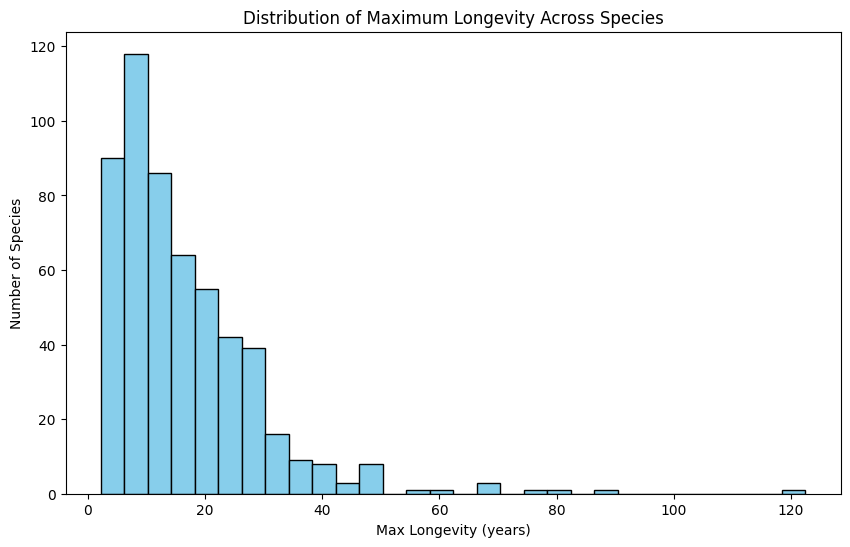

In [82]:
df_clean = df.dropna(subset=["Maximum longevity (yrs)", "Body mass (g)"])

# Histogram of maximum lifespans
plt.figure(figsize=(10,6))
plt.hist(df_clean['Maximum longevity (yrs)'], bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of Maximum Longevity Across Species")
plt.xlabel("Max Longevity (years)")
plt.ylabel("Number of Species")
plt.show()

# EXERCISE 8: Histogram (Matplotlib)

1. What does the shape of the distribution look like (e.g. skewed or normal)? / Як виглядає форма розподілу данних?
2. What happens if you increase or decrease the number of bins? / Що стаєтсья якщо и збільшуєте або зменшуєте кількість стовпців?
3. Which lifespan range contains the most species? / Який діапазон тривалості життя включає в себе більшість видів?

In [ ]:
#### Your code here ####


# Step 9: Scatter Plot
- Scatter plots allow us to compare values from two columns against each other.

---
**Українською:** Step 9: діаграма розсіювання. Тут пояснюється візуалізація даних: графіки допомагають побачити розподіли, звʼязки між змінними та можливі викиди.


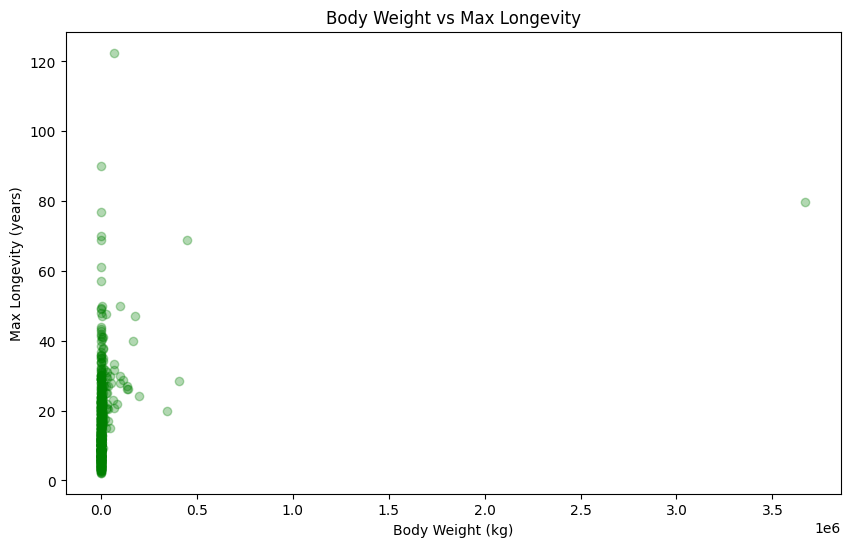

In [73]:
# Scatter Plot - Body Weight vs Max Longevity
plt.figure(figsize=(10,6))
plt.scatter(df_clean['Body mass (g)'], df_clean['Maximum longevity (yrs)'], alpha=0.3, color='green') #alpha score show density of dots in dataset
plt.title("Body Weight vs Max Longevity")
plt.xlabel("Body Weight (kg)")
plt.ylabel("Max Longevity (years)")
plt.show()

# EXERCISE 9.1: Simple Scatter

Create a scatter plot for each of the following questions to find the answers. / Створіть діаграму розсіювання для кожного з наступних питань, щоб знайти відповіді.
1. Do larger animals tend to live longer? / Чи живуть більші тварини довше?
2. Are there any obvious outliers? / Чи є якість очевидні аутлаєри?
3. What happens if you change the transparency (alpha)? / Що стається якщо ви змінюєте прозорість точок?

In [ ]:
#### Your code here ####


# Improving our figures
- Adding annotations with colour and labelling certain datapoints makes our figures more informative
- Visualising points on the log scale can help by separating our data and making it more understandable

---
**Українською:** Improving our figures. Цей блок пояснює роботу з pandas, NumPy та matplotlib: завантаження даних, фільтрацію, обробку пропущених значень, групування, числові операції та побудову графіків.


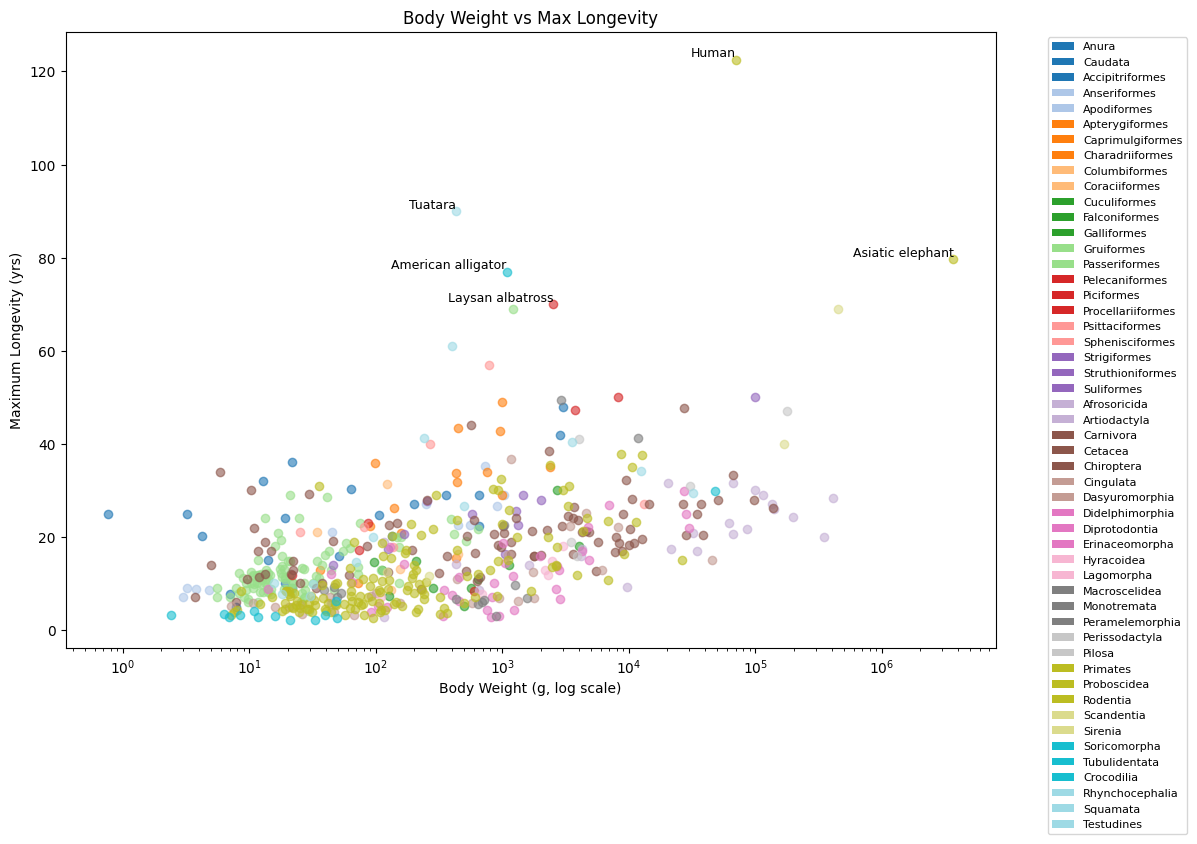

In [83]:
# Step 8.2: Scatter Plot - colored by Order and label longest-lived species
plt.figure(figsize=(12,8))

# Get unique orders and assign colors <- Colour each point by the phylogenetic tree
orders = df_clean['Order'].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(orders)))
order_color_map = dict(zip(orders, colors))

# Plot each point with color based on Order
for idx, row in df_clean.iterrows():
    plt.scatter(row['Body mass (g)'], row['Maximum longevity (yrs)'], 
                color=order_color_map[row['Order']], alpha=0.6)

# Label the top 5 longest-lived species
top_longest = df_clean.nlargest(5, 'Maximum longevity (yrs)')
for idx, row in top_longest.iterrows():
    plt.text(row['Body mass (g)'], row['Maximum longevity (yrs)'], 
             row['Common name'], fontsize=9, ha='right', va='bottom')

# Plot the layers for the Matplotlib figure - Title & Axis 
plt.xscale('log')  # log scale for better visualization
plt.title("Body Weight vs Max Longevity")
plt.xlabel("Body Weight (g, log scale)")
plt.ylabel("Maximum Longevity (yrs)")

# Create a legend for Orders
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, label=order) for order, color in order_color_map.items()]
plt.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.show()

# EXERCISE 9.2: Annotated scatter plot

1. Which order contains the longest-lived species?  / В якому порядку найбільш довгоживучі види?
2. Why is a log scale useful for body weight? / Чому логарифмічна шкала длямаси є зручною?
3. What happens if you label more than 5 species? / Що буде якщо ви додасте підписи до більш ніж 5 видів?
4. Can you identify any clusters of related species? / Чи ви бачите якісь кластери пов'язаних видів?



In [ ]:
#### Your code here ####


# Step 10: Do heavier animals really live longer?
- We can add a regression live to out plots to calculate the correlation between two variables.

---
**Українською:** Step 10: Do heavier animals really live longer?. Тут пояснюється візуалізація даних: графіки допомагають побачити розподіли, звʼязки між змінними та можливі викиди.


Correlation between body weight and longevity: 0.27


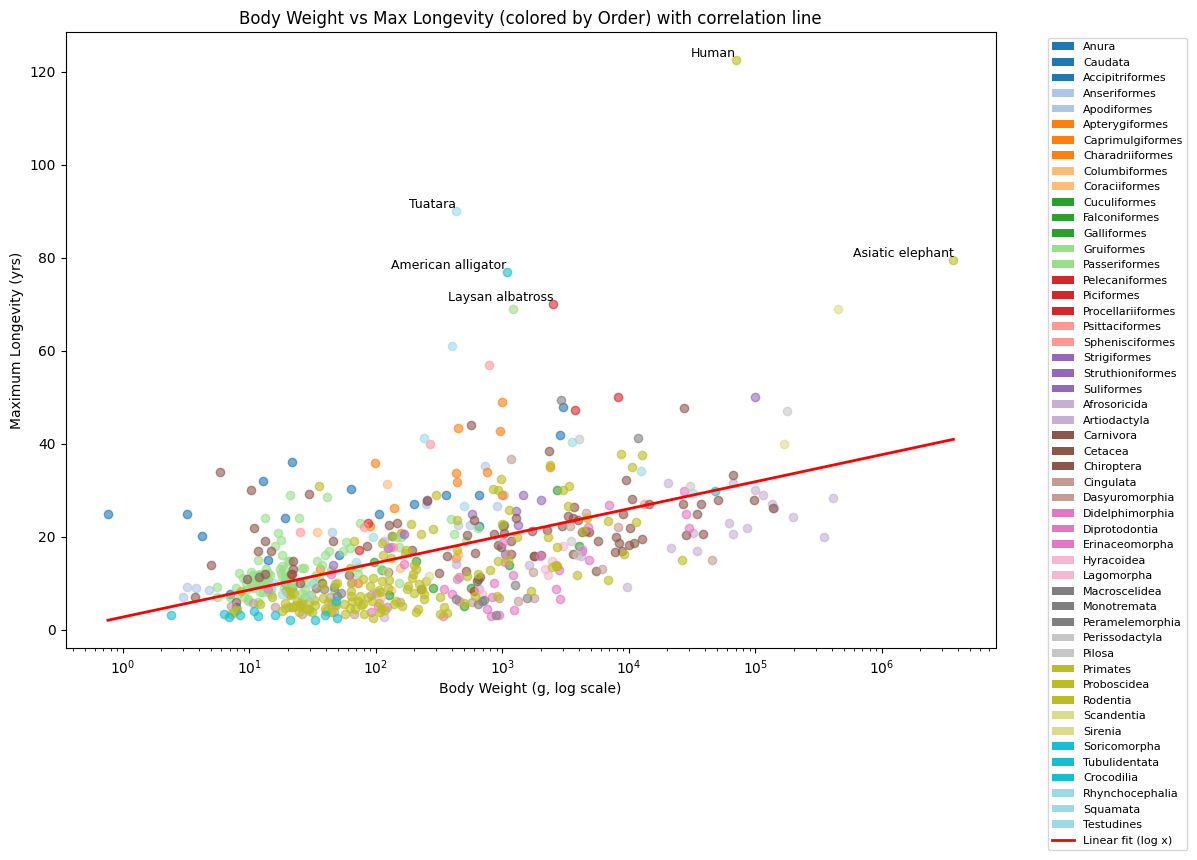

In [84]:
correlation = df_clean['Body mass (g)'].corr(df_clean['Maximum longevity (yrs)'])
print(f"Correlation between body weight and longevity: {correlation:.2f}")

# Prepare x and y
x = df_clean['Body mass (g)']
y = df_clean['Maximum longevity (yrs)']

# Take log of x for fitting (because x-axis is log scale)
log_x = np.log10(x)

# Linear regression in log space: y = slope * log10(x) + intercept
slope, intercept = np.polyfit(log_x, y, 1)

# Create points for the regression line
x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = slope * np.log10(x_fit) + intercept

# --- Plot ---
plt.figure(figsize=(12,8))

# Scatter points colored by Order
for idx, row in df_clean.iterrows():
    plt.scatter(row['Body mass (g)'], row['Maximum longevity (yrs)'], 
                color=order_color_map[row['Order']], alpha=0.6)

# Label the top 5 longest-lived species
top_longest = df_clean.nlargest(5, 'Maximum longevity (yrs)')
for idx, row in top_longest.iterrows():
    plt.text(row['Body mass (g)'], row['Maximum longevity (yrs)'], 
             row['Common name'], fontsize=9, ha='right', va='bottom')

# Plot the regression line
plt.plot(x_fit, y_fit, color='red', linewidth=2, label=f'Linear fit (log x)')

plt.xscale('log')  # log scale for better visualization
plt.title("Body Weight vs Max Longevity (colored by Order) with correlation line")
plt.xlabel("Body Weight (g, log scale)")
plt.ylabel("Maximum Longevity (yrs)")

# Legend for both orders and regression line
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, label=order) for order, color in order_color_map.items()]
plt.legend(handles=legend_elements + [plt.Line2D([0], [0], color='red', lw=2, label='Linear fit (log x)')],
           bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.show()

# Step 11: What is the distribution of birth weights for animals which live longer than 5 years? 
- Group the distribution by taxonomic class.

---
**Українською:** Step 11: What is the distribution of birth weights for animals which live longer than 5 years?. Цей блок пояснює роботу з pandas, NumPy та matplotlib: завантаження даних, фільтрацію, обробку пропущених значень, групування, числові операції та побудову графіків.


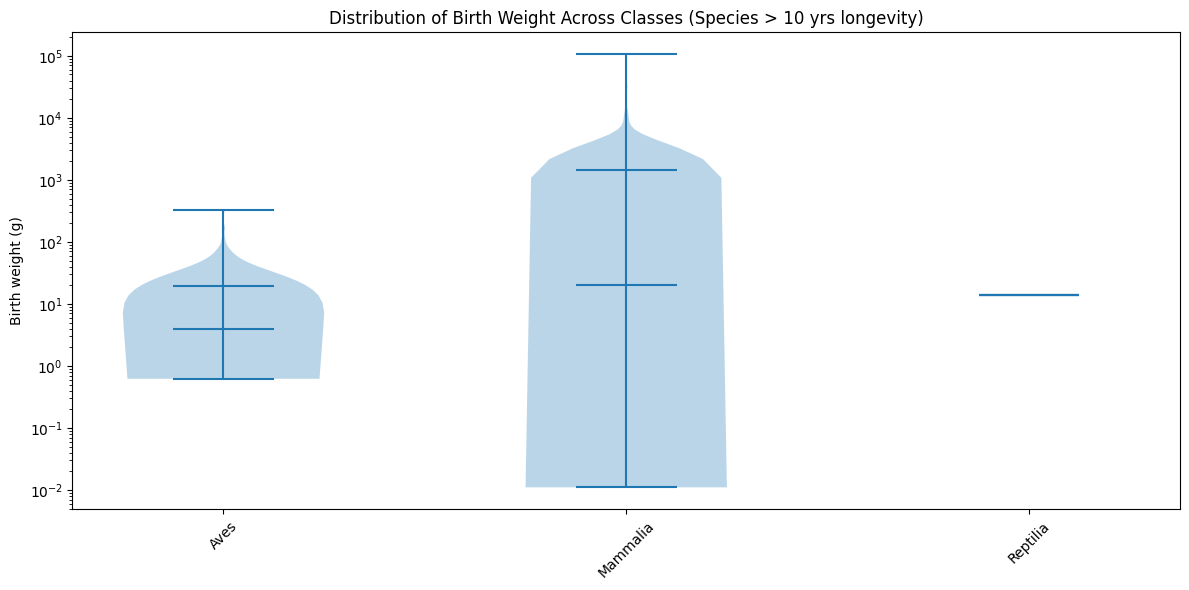

In [85]:
# Filter for species with longevity > 5 years
long_lived = df_clean[df_clean['Maximum longevity (yrs)'] > 5]

# Prepare data for each Class
classes = long_lived['Class'].unique()
data = []

filtered_classes = []
for cls in classes:
    birth_weights = long_lived[long_lived['Class'] == cls]['Birth weight (g)'].dropna()
    if len(birth_weights) > 0:  # Only keep non-empty arrays
        data.append(birth_weights)
        filtered_classes.append(cls)

# Create the violin plot
plt.figure(figsize=(12,6))
plt.violinplot(data, showmeans=True, showmedians=True)

# Set x-ticks to class names
plt.xticks(ticks=np.arange(1, len(filtered_classes)+1), labels=filtered_classes, rotation=45)
plt.yscale('log')
plt.ylabel("Birth weight (g)")
plt.title("Distribution of Birth Weight Across Classes (Species > 10 yrs longevity)")
plt.tight_layout()
plt.show()

# Step 11: Challenge for Students
## For each of the following visualise the answer and summarise the results in 2-3 sentences. 
- Which Class of animals has the highest average longevity?  / В якому класі тварини найбілш довгоживучі?
- Does litter size correlate with longevity? / Чи пов'язана кількість потомства з тривалістю життя?
- Which Order of animals has the highest average longevity? / В якому порядку тварин найбільша середня тривалість життя?
- Create a scatter plot of Body Mass vs Maximum Longevity only for mammals. What is the correlation? / Побудуйте графік розкиду масси тіла проти максимальної тривалості життя тільки дял ссавців. Якою є кореляція?
- Identify species with unexpected lifespans (e.g., small animals that live unusually long). / Визначте види з незвичайною тривалістю життя
- Compare birds and mammals in terms of average lifespan using a bar chart. / Порівняйте птахів та ссавців за їх середньою тривалістю життя використовуючи стовпчастий графік
- Does longevity always correlate with Female (or Male) maturity (days)? Identify species who grow up fast despite being long lived. / Чи тривалість життя корелює з дозріванням для самців чи самок? Визначте види які дорослішають швидше.